In [2]:
import numpy as np 
import pandas as pd 

In [3]:
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [8]:
numerical_col=df.select_dtypes(include=["int64" , "float64"]).columns
catg_col=df.select_dtypes(include=["object"]).columns
len(numerical_col)

7

In [9]:
len(catg_col)

5

In [10]:
missing=df.isnull().sum()
missing=missing[missing > 0].sort_values(ascending = False)
missing

Cabin       687
Age         177
Embarked      2
dtype: int64

In [11]:
df["Age"].head(5)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [12]:
df["Survived"].sum()

np.int64(342)

In [13]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df=df.drop("Cabin" ,axis =1 )

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:

df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [17]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X = pd.get_dummies(X, drop_first=True)  # encode Sex, Embarked, etc.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier
Dtc=DecisionTreeClassifier(criterion= 'entropy', max_depth=3,random_state=42)
Dtc.fit(X_train,y_train)
y_pre =Dtc.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pre)

0.7988826815642458

GridSearchCV

In [19]:
param_dist={
    "criterion":["gini",'entropy'],
    'max_depth':[1,2,3,4,5,6,7,None]
}

In [55]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(Dtc , param_grid=param_dist , cv=10 , n_jobs=-1)

In [56]:
grid.fit(X_train , y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [57]:
grid.best_score_

np.float64(0.8244522691705791)

In [58]:
grid.best_params_

{'criterion': 'entropy', 'max_depth': 3}

In [59]:
grid.error_score

nan

[Text(0.5, 0.875, 'x[5] <= 0.5\nentropy = 0.955\nsamples = 712\nvalue = [444, 268]'),
 Text(0.25, 0.625, 'x[0] <= 2.5\nentropy = 0.829\nsamples = 245\nvalue = [64, 181]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= 2.5\nentropy = 0.235\nsamples = 130\nvalue = [5, 125]'),
 Text(0.0625, 0.125, 'entropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1875, 0.125, 'entropy = 0.201\nsamples = 128\nvalue = [4, 124]'),
 Text(0.375, 0.375, 'x[4] <= 23.35\nentropy = 1.0\nsamples = 115\nvalue = [59.0, 56.0]'),
 Text(0.3125, 0.125, 'entropy = 0.979\nsamples = 94\nvalue = [39, 55]'),
 Text(0.4375, 0.125, 'entropy = 0.276\nsamples = 21\nvalue = [20, 1]'),
 Text(0.75, 0.625, 'x[1] <= 6.5\nentropy = 0.694\nsamples = 467\nvalue = [380, 87]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= 2.5\nentropy = 0.902\nsamples = 22\nvalue = [7.0, 15.0]'),
 Text(0.5625, 0.125, 'entropy = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.6875, 0.125, 'entropy = 0.544\nsamples = 8\nvalue = 

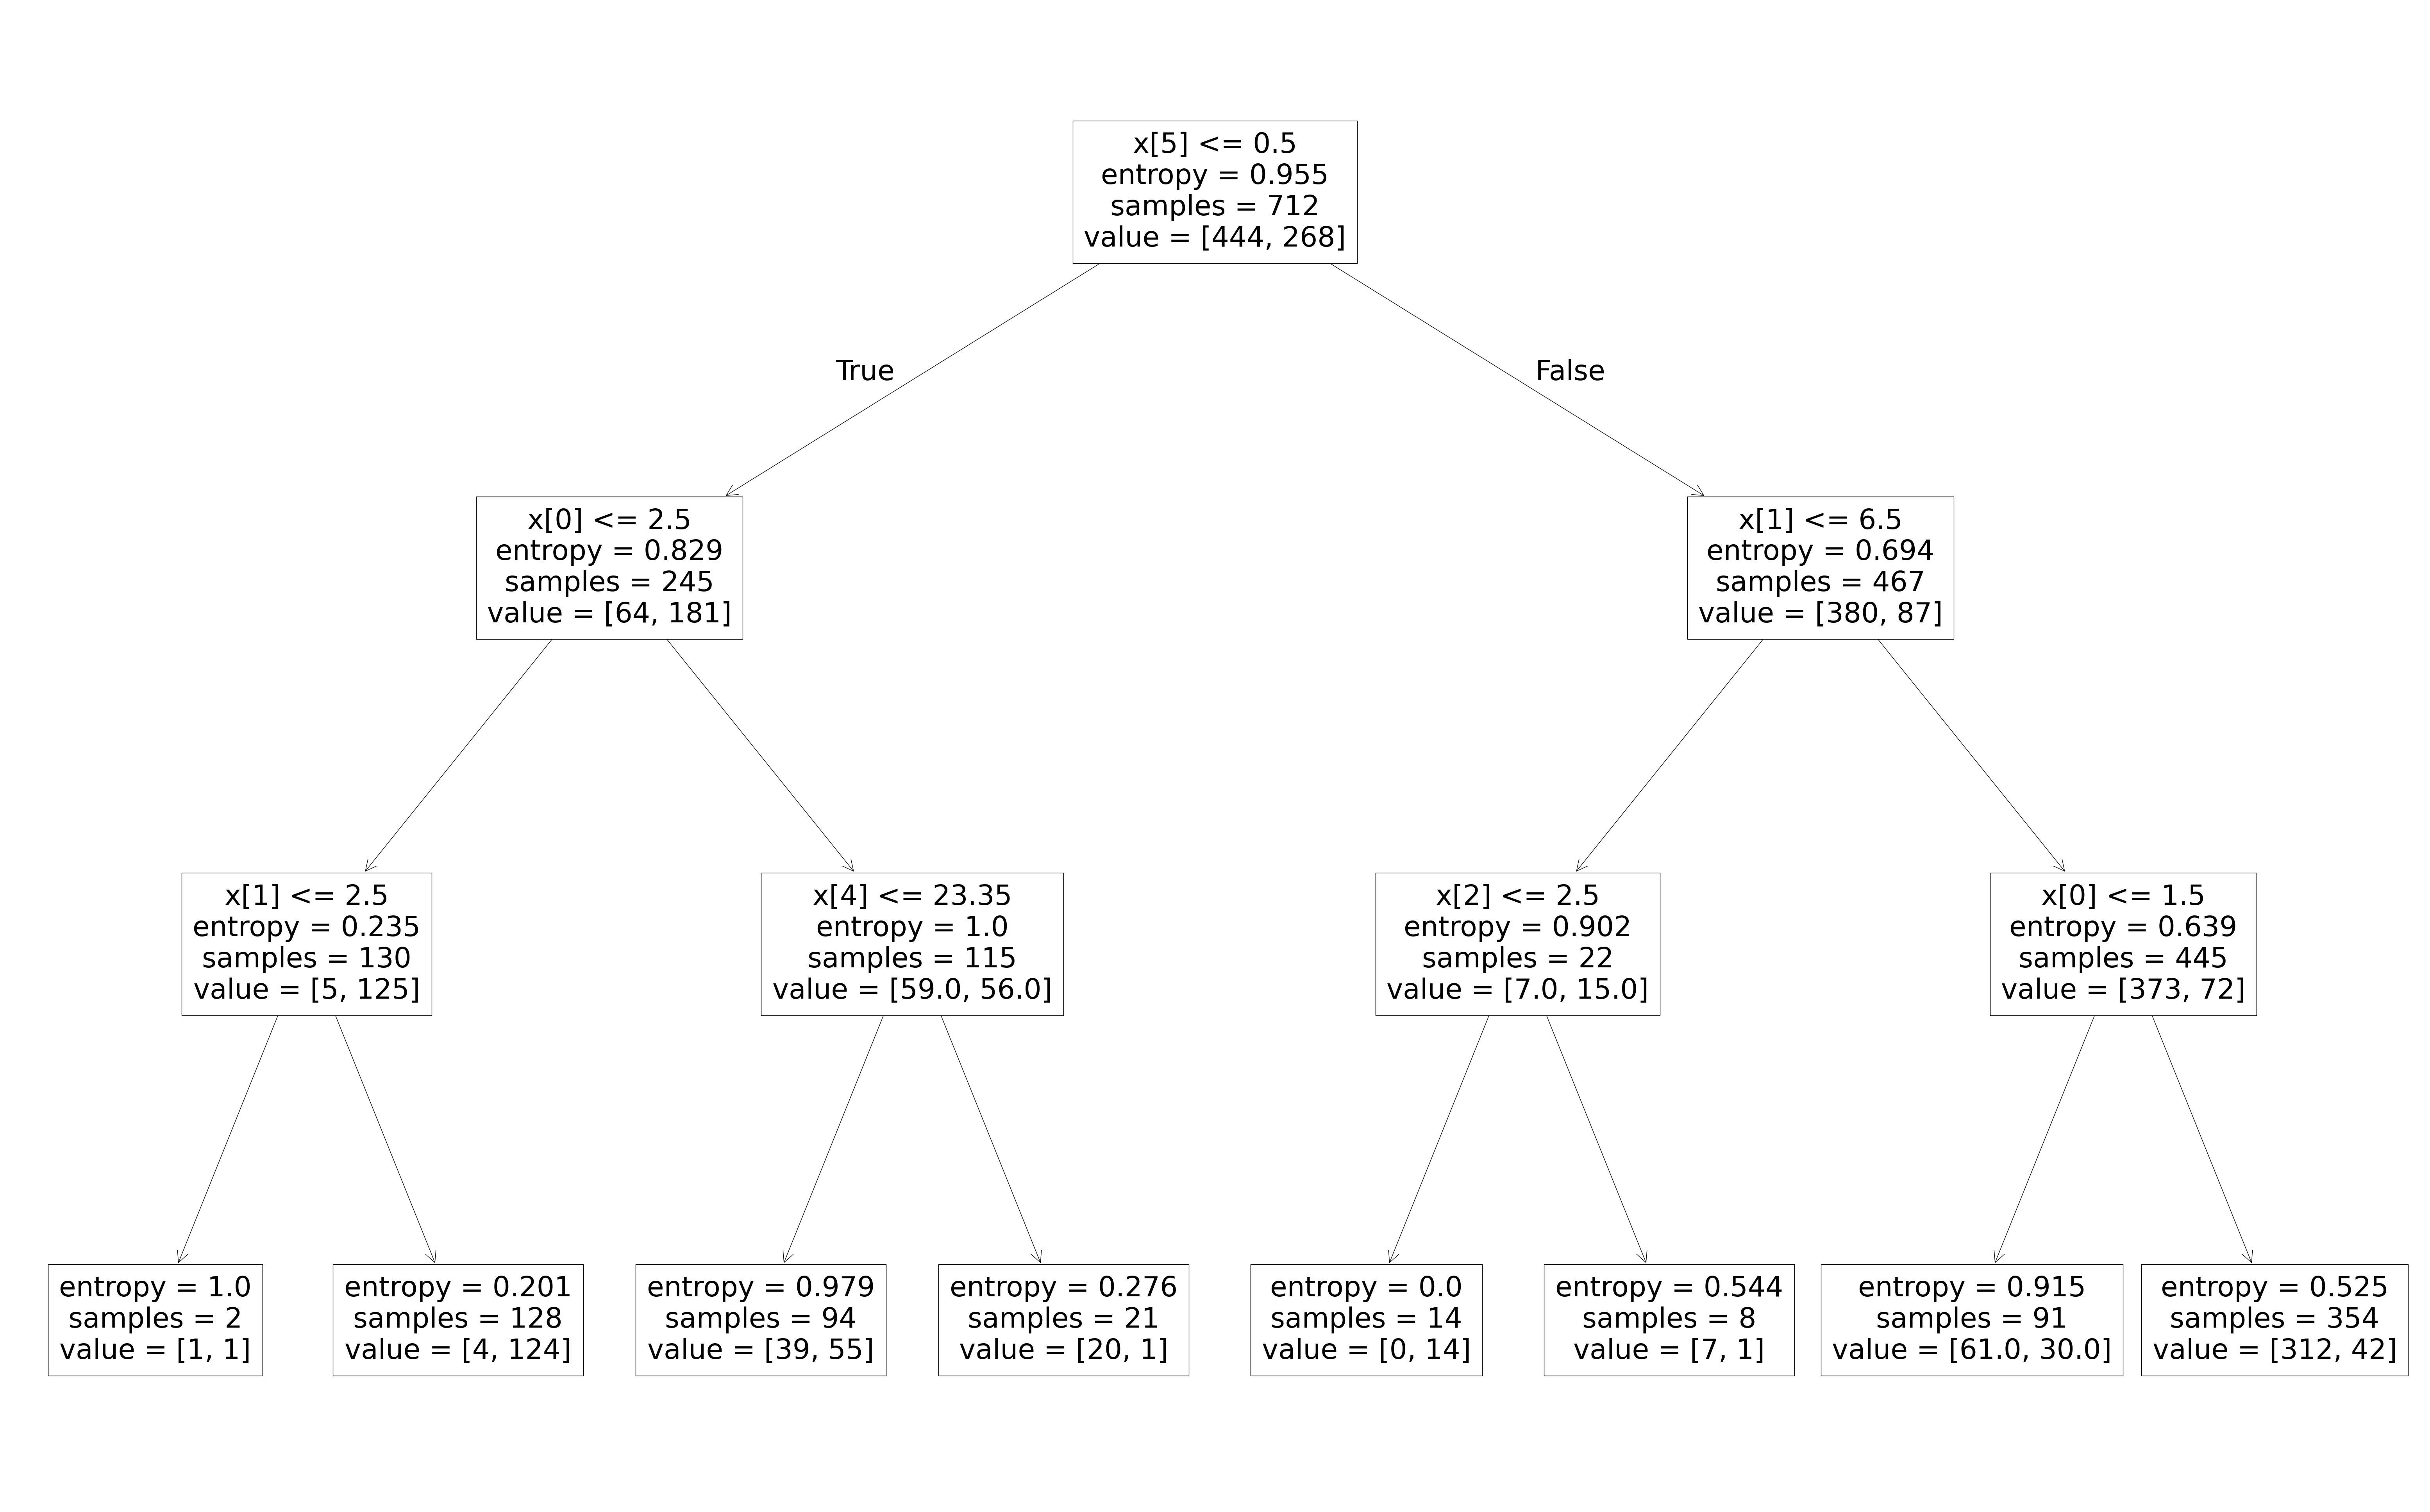

In [60]:
from sklearn.tree import plot_tree
from matplotlib.pylab import rcParams
rcParams["figure.figsize"]=80,50
plot_tree(Dtc)

 LogisticRegression

In [61]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(max_iter=1000 )
lg.fit(X_train , y_train)
y_pred =lg.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.8100558659217877

In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [64]:
X_train.shape

(712, 8)

In [65]:
X_test.shape

(179, 8)

Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42 ,oob_score=True)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
#print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8212290502793296


In [67]:
rf.oob_score_

0.7963483146067416

GridSearchCV

In [68]:
param_grid_r={
    "n_estimators" : [20,60,100],
    "max_depth" :[1,5,None],
     "bootstrap":[True,False],
    "criterion":['gini','entropy'],
    'max_features':[0.2,0.6],
    'max_samples':[0.5,0.75]

}

In [69]:
rf_grid=GridSearchCV(rf , param_grid=param_grid_r , cv=5 , n_jobs=-1)

In [70]:
rf_grid.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
360 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 430, in fit
    raise ValueErr

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'max_depth': [1, 5, ...], 'max_features': [0.2, 0.6], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,20


In [71]:
rf_grid.best_params_

{'bootstrap': True,
 'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 0.6,
 'max_samples': 0.5,
 'n_estimators': 20}

In [72]:
rf_grid.best_score_

np.float64(0.8356347877474638)

AdaBoostClassifierada

In [73]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(algorithm="SAMME",n_estimators=200, random_state=42)
ada.fit(X_train, y_train)



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,estimator,None
,n_estimators,200
,learning_rate,1.0
,algorithm,'SAMME'
,random_state,42


In [74]:
y_pred_ada = ada.predict(X_test)
accuracy_score(y_test ,y_pred_ada)

0.8100558659217877

GridSearchCV

In [75]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    "algorithm":["SAMME","SAMME.R"]
}

In [76]:
from sklearn.model_selection import GridSearchCV



ada_grid = GridSearchCV(ada, param_grid=param_grid_ada, cv=5, n_jobs=-1)
ada_grid.fit(X_train, y_train)

print(ada_grid.best_params_)
print(ada_grid.best_score_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
45 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    

{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
0.8075544174135724


In [77]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
gb = GradientBoostingClassifier(random_state=42)

# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_gb))


Accuracy: 0.8044692737430168


In [78]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", grid.score(X_test, y_test))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score: 0.8342460356544864
Test Accuracy: 0.8100558659217877


In [96]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb=XGBClassifier(colsample_bytree= 0.8, learning_rate= 0.1, max_depth= 3,n_estimators=50, subsample=0.8)
xgb.fit(X_train ,y_train)
y_pred_xg=xgb.predict(X_test)
accuracy_score(y_test, y_pred_xg)

0.7932960893854749

In [53]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_grid = GridSearchCV(xgb, param_grid=param_grid_xgb, cv=5, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)
print("Test Accuracy:", xgb_grid.score(X_test, y_test))

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
0.8398699891657637
Test Accuracy: 0.8100558659217877


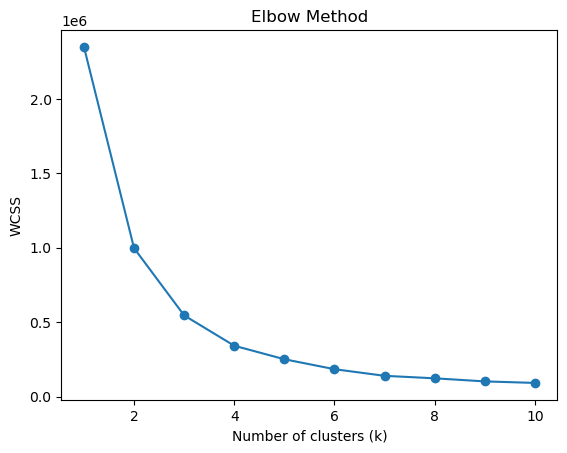

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select numeric features for clustering (example: Age, Fare from Titanic, or Income/Spending from Mall dataset)
X_cluster = df[['Age', 'Fare']]  # adjust to your chosen dataset/columns

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

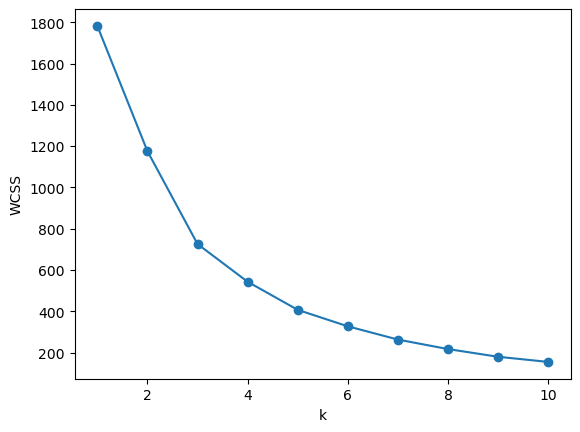

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)  # X_cluster = df[['Age','Fare']]

# Rerun elbow method on SCALED data
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

In [143]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

std=StandardScaler()
X_train_std=std.fit_transform(X_train)
X_test_std=std.transform(X_test)

pca=PCA(n_components=0.95)

X_train_pca=pca.fit_transform(X_train_std)
X_test_pca=pca.transform(X_test_std)


In [144]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42 ,oob_score=True)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
#print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8044692737430168


In [145]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb=XGBClassifier(colsample_bytree= 0.8, learning_rate= 0.1, max_depth= 3,n_estimators=50, subsample=0.8)
xgb.fit(X_train_pca ,y_train)
y_pred_xg=xgb.predict(X_test_pca)
accuracy_score(y_test, y_pred_xg)

0.8212290502793296

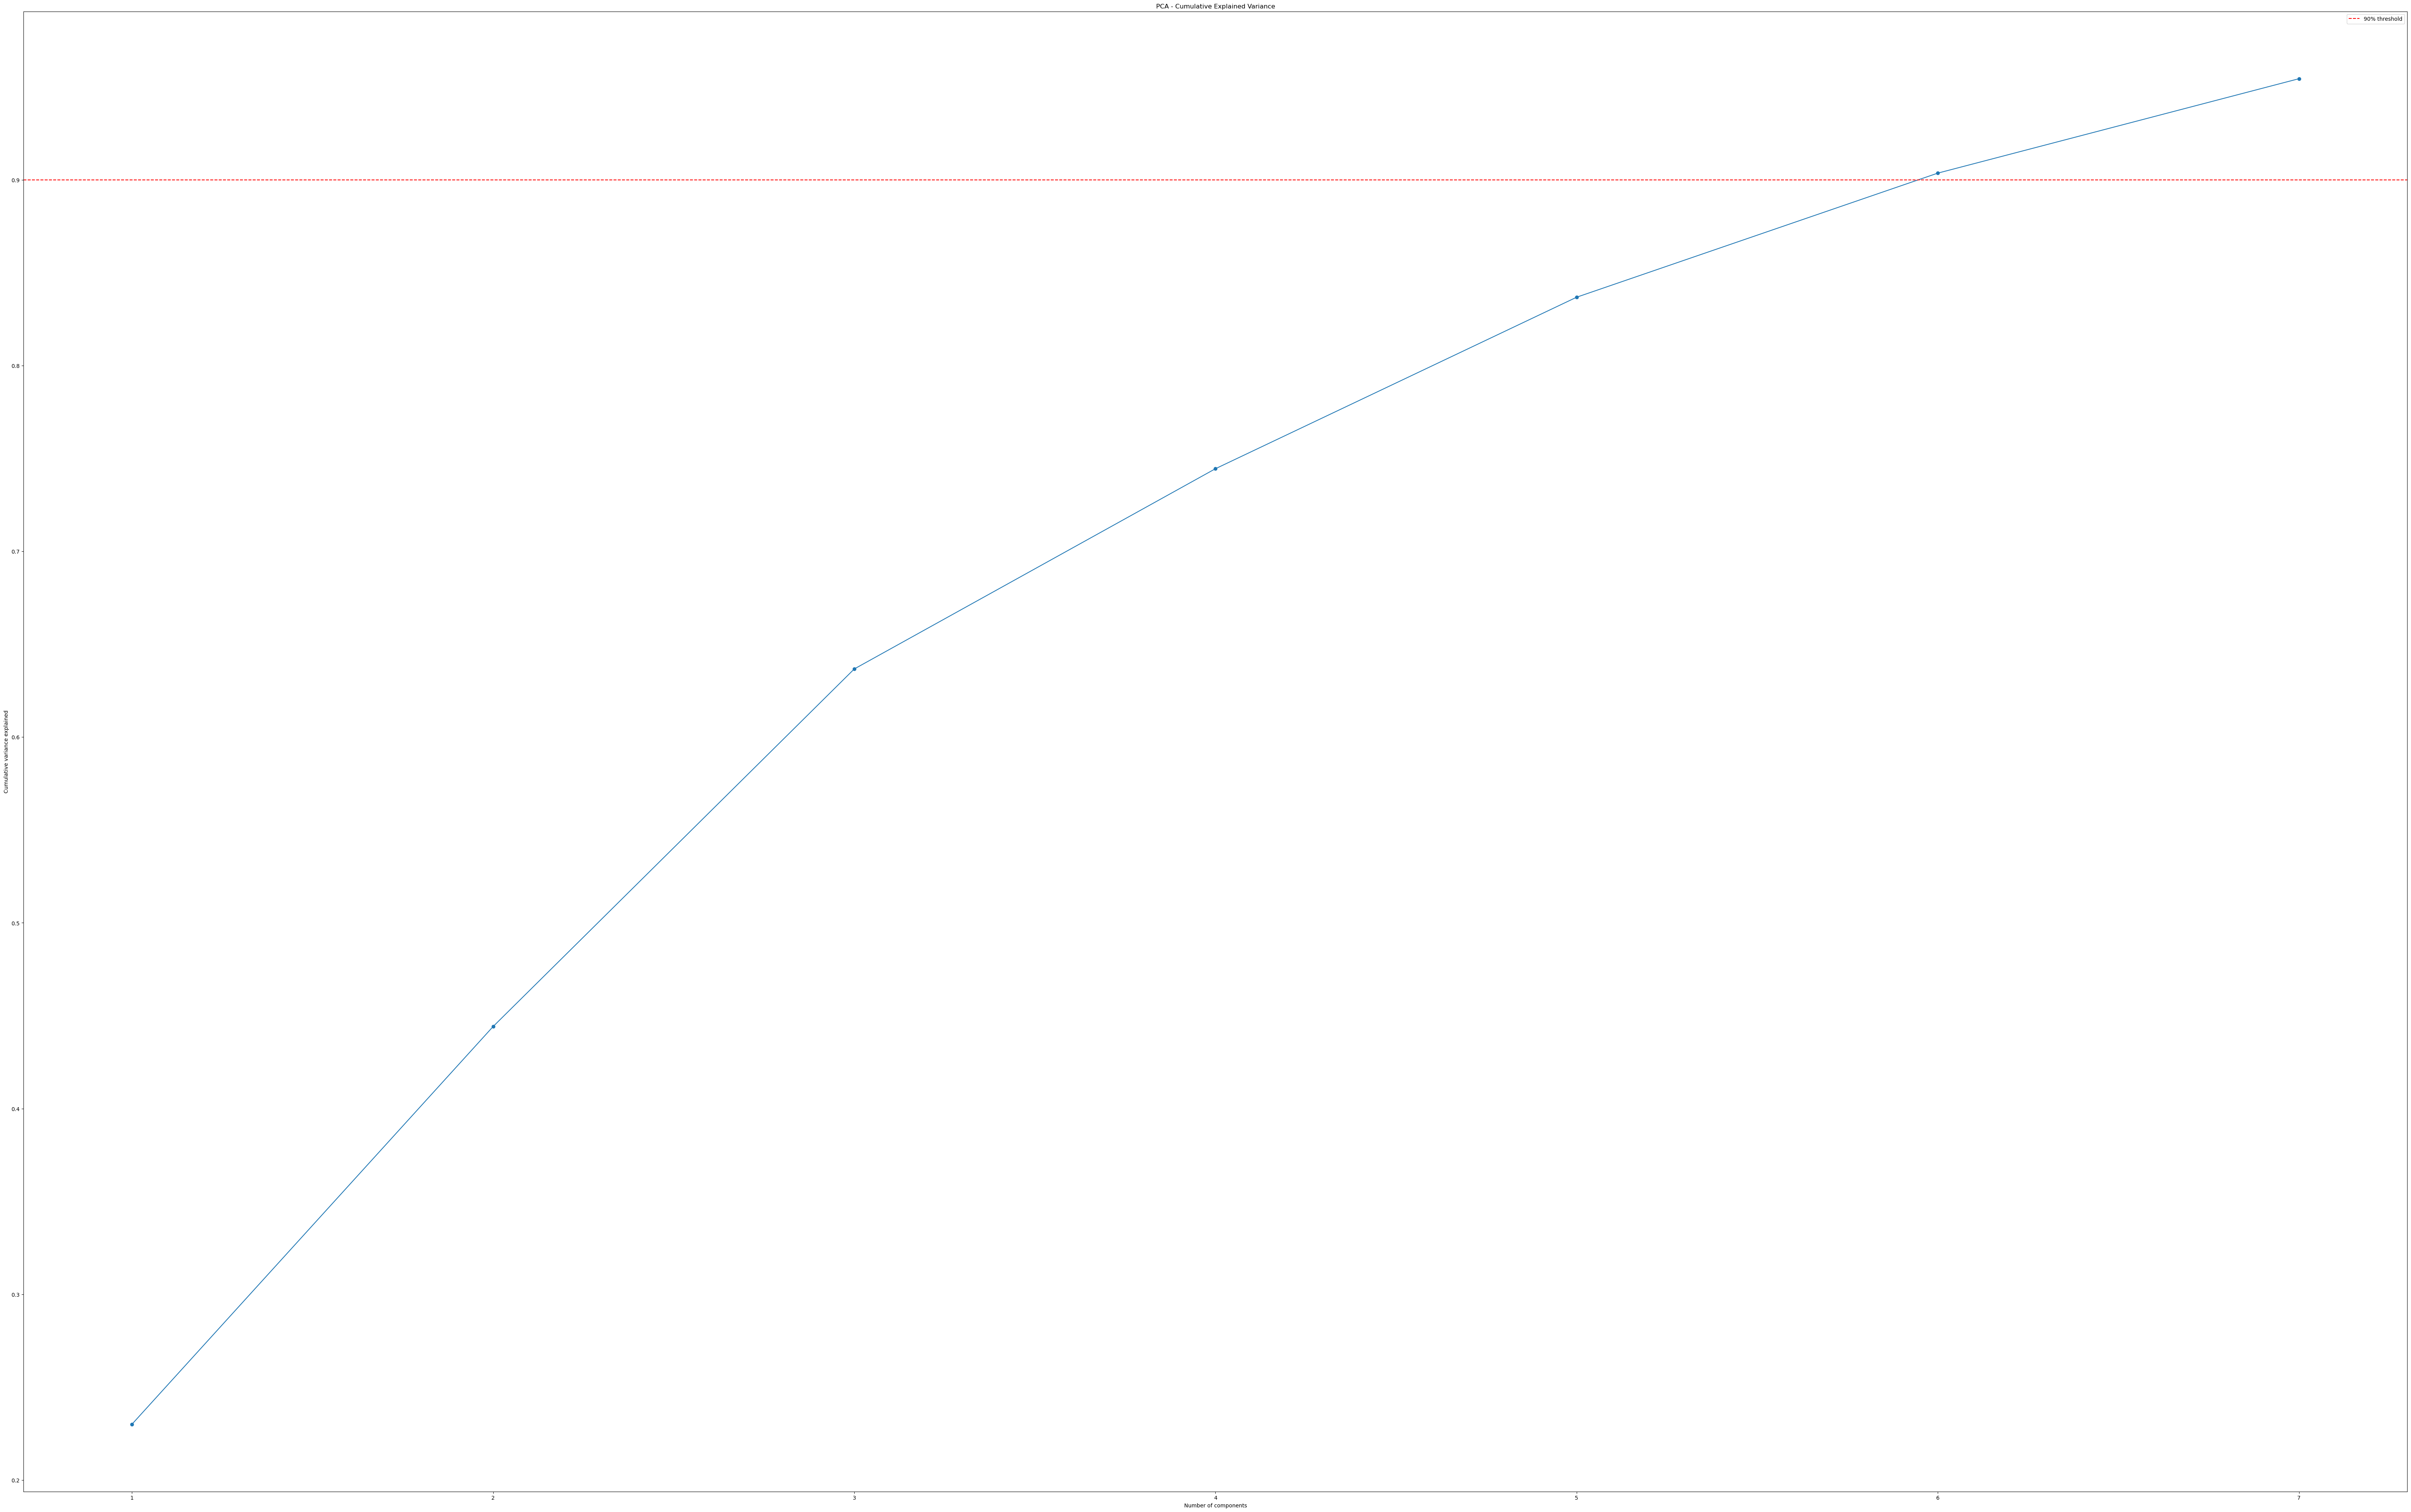

In [146]:
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.legend()
plt.title('PCA - Cumulative Explained Variance')
plt.show()

In [150]:
pca.explained_variance_ratio_.sum()

np.float64(0.954466962573336)

In [21]:
from sklearn.linear_model import Perceptron
pr=Perceptron()
pr.fit(X_train,y_train)
y_pree=pr.predict(X_test)
accuracy_score(y_test,y_pree)

0.6089385474860335